In [4]:
!pip install librosa scipy matplotlib numpy statsmodels --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Подключение библиотек

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import statsmodels.api as sm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [11, 7]
plt.rcParams['figure.dpi'] = 100

### Задание 1

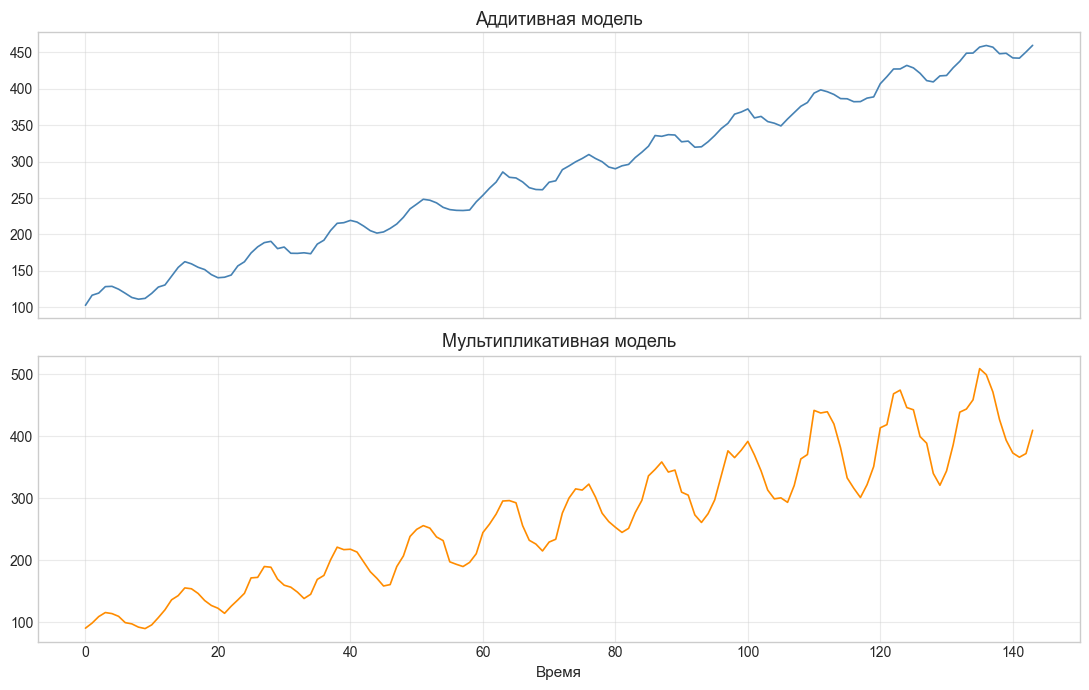

In [6]:
t = np.arange(144)
season = 15 + np.sin(2 * np.pi * t / 12) * 15
trend = t * 2.5 + 90
noise = np.random.normal(loc=0.0, scale=2.5, size=len(t))

add_model = trend + season + noise

season_mult = 1 + np.sin(2 * np.pi * t / 12) * 0.18
noise_mult = np.random.normal(loc=1.0, scale=0.025, size=len(t))
mult_model = trend * season_mult * noise_mult

dec_add = seasonal_decompose(add_model, model='additive', period=12)
dec_mult = seasonal_decompose(mult_model, model='multiplicative', period=12)
stl_res = STL(add_model, period=12).fit()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t, add_model, color='steelblue', linewidth=1.2)
axes[0].set_title('Аддитивная модель', fontsize=13)
axes[0].grid(True, alpha=0.4)

axes[1].plot(t, mult_model, color='darkorange', linewidth=1.2)
axes[1].set_title('Мультипликативная модель', fontsize=13)
axes[1].set_xlabel('Время', fontsize=11)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Задание 2

In [7]:
series_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values
series_B = sm.datasets.co2.load_pandas().data['co2'].values

print(f"series_A: {len(series_A)}, series_B: {len(series_B)}")

series_A: 144, series_B: 2284


### Задание 3

In [8]:
series_A = sm.datasets.get_rdataset("AirPassengers", "datasets").data["value"].values
series_B = sm.datasets.co2.load_pandas().data['co2'].dropna().values

print(f"series_A: {len(series_A)}, series_B: {len(series_B)}")

series_A: 144, series_B: 2225


Данные AirPassengers лучше описываются мультипликативной моделью. Сезонная амплитуда увеличивается вместе с трендом.

Данные CO2 хорошо подходят для аддитивной модели. Амплитуда сезонных колебаний остаётся постоянной.